# ARTI 403 – Image Processing
## Lab 2 — Digital Image Fundamentals

**Student name:** Ahmed Albuainain
**Student ID:** 2240006128
**Section:** 7MA1
**Date:** 14 September 2026

---

### Outcome #1
Explain how digital images are represented and manipulated in a computer.

### Contents
| Part | Description |
|---|---|
| Part 0 | Environment check and preparing the images |
| Part 1 | Image sampling and quantization |
| Part 2 | Arithmetic operations on images |
| Part 3 | Sets and logical operations |
| Task 1 | Change the sampling and quantization parameters and observe the effects |
| Task 2 | Subtraction, adding a constant, set difference, symmetric difference, intersection |

---
## Part 0 — Environment check and preparing the images

The lab manual reads its images from `../images/`. This notebook resolves that path
automatically: if an `images` folder exists one level up it is used, otherwise a local
`images` folder is created next to the notebook.

Four images are needed:

| File | What it is |
|---|---|
| `gray_256.tif` | 256x256 grayscale image |
| `cameraman.tif` | the classic 512x512 cameraman test image |
| `A.png` | binary image — set **A** (a disk) |
| `B.png` | binary image — set **B** (a square) |

The grayscale images come from the `skimage.data` samples used in Lab 1. `A.png` and `B.png`
are generated as two deliberately **overlapping** binary shapes, which is what makes the set
operations in Part 3 easy to read by eye.

In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import skimage as ski
from skimage.transform import resize
from skimage.util import img_as_ubyte

print("Python  :", sys.version.split()[0])
print("NumPy   :", np.__version__)
print("OpenCV  :", cv2.__version__)
print("Pillow  :", Image.__version__ if hasattr(Image, "__version__") else "installed")

%matplotlib inline

Python  : 3.13.5
NumPy   : 2.3.5
OpenCV  : 5.0.0
Pillow  : 12.1.0


In [2]:
# resolve the images folder: '../images' if it exists, otherwise './images'
IMG_DIR = os.path.join("..", "images")
if not os.path.isdir(IMG_DIR):
    IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs("output", exist_ok=True)

def img_path(name):
    return os.path.join(IMG_DIR, name)

# --- grayscale test images -------------------------------------------------
if not os.path.exists(img_path("gray_256.tif")):
    g = img_as_ubyte(resize(ski.data.coins(), (256, 256), anti_aliasing=True))
    Image.fromarray(g).save(img_path("gray_256.tif"))

if not os.path.exists(img_path("cameraman.tif")):
    Image.fromarray(ski.data.camera()).save(img_path("cameraman.tif"))

# --- binary sets A and B ---------------------------------------------------
if not (os.path.exists(img_path("A.png")) and os.path.exists(img_path("B.png"))):
    size = 400
    rows, cols = np.ogrid[:size, :size]

    # A = a disk centred left of the middle
    A = np.zeros((size, size), dtype=np.uint8)
    A[(rows - 200) ** 2 + (cols - 160) ** 2 <= 120 ** 2] = 255

    # B = a square shifted right, so that A and B overlap
    B = np.zeros((size, size), dtype=np.uint8)
    B[120:300, 200:380] = 255

    Image.fromarray(A).save(img_path("A.png"))
    Image.fromarray(B).save(img_path("B.png"))

print("images folder:", os.path.abspath(IMG_DIR))
print("contents     :", sorted(os.listdir(IMG_DIR)))

images folder: c:\Users\ahmad\OneDrive\Desktop\im Labs\lab1\Lab 2\images
contents     : ['A.png', 'B.png', 'cameraman.tif', 'gray_256.tif']


A small helper used throughout the notebook so that every figure is written the same way.

In [3]:
def show(images, titles, cols=3, size=4, cmap='gray', suptitle=None):
    """Display a list of images in a grid with their titles."""
    n = len(images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(size * cols, size * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, im, t in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap, vmin=0, vmax=255)
        ax.set_title(t, fontsize=11)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()

---
## Part 1 — Image sampling and quantization

These are the two steps that turn a continuous scene into a digital image:

* **Sampling** decides *how many* pixels the image has — its spatial resolution.
  Reducing the sampling rate throws away pixel positions and produces blocky detail.
* **Quantization** decides *how many different values* each pixel may take — its intensity
  resolution. Reducing the number of levels produces flat bands of constant grey.

One acts on the grid, the other on the values stored in it.

### 1.1 The three functions from the manual

In [4]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor),
                               interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

### 1.2 Running the manual's example

The parameters given in the manual are a sampling factor of 14 and 9 quantization levels.

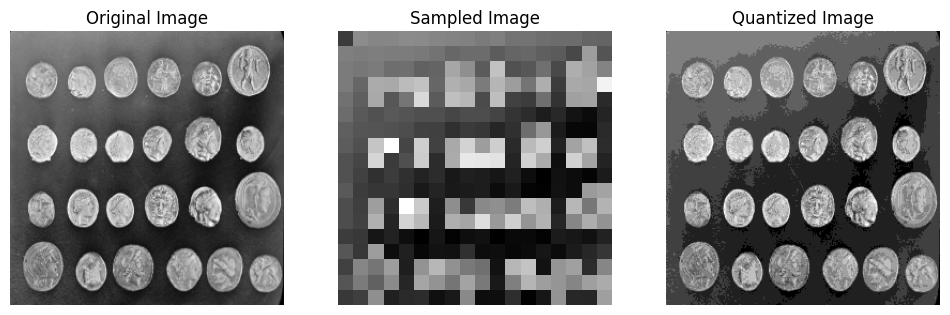

original : (256, 256) | 236 grey levels
sampled  : (18, 18) | 151 grey levels
quantized: (256, 256) | 9 grey levels


In [5]:
image_path = img_path('gray_256.tif')
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

print("original :", original_image.shape, "|", len(np.unique(original_image)), "grey levels")
print("sampled  :", sampled_image.shape, "|", len(np.unique(sampled_image)), "grey levels")
print("quantized:", quantized_image.shape, "|", len(np.unique(quantized_image)), "grey levels")

**A note on the two figures.** Matplotlib rescales every image to the same box on screen,
so the sampled image *looks* the same size as the original even though it is much smaller.
The printed shapes show what actually happened: sampling changed the array size, quantization
did not. Quantization changed the number of distinct values instead.

### 1.3 Why the quantized image does not have exactly 9 levels

The formula `np.floor(image / (256 // levels)) * (256 // levels)` uses **integer** division
for the step size. With `levels = 9` the step is `256 // 9 = 28`, so the values it can produce
are 0, 28, 56, ... up to `floor(255 / 28) * 28 = 252` — that is **10** possible values, not 9.

A particular image may show fewer than the possible count simply because it contains no pixel
bright enough to reach the top value, which is why the table below reports both numbers.
The formula is exact only when `levels` divides 256, i.e. for 2, 4, 8, 16, 32, 64, 128, 256.

In [6]:
print(f"{'levels':<9}{'step':<7}{'distinct values':<32}{'exact?'}")
print("-" * 60)
for lv in [2, 3, 4, 8, 9, 16, 32, 64]:
    step = 256 // lv
    q = quantize_image(original_image, lv)
    got = len(np.unique(q))
    # the theoretical count over the full 0..255 range
    theoretical = len(np.unique(np.floor(np.arange(256) / step) * step))
    print(f"{lv:<9}{step:<7}{f'{theoretical} possible, {got} in this image':<32}"
          f"{'yes' if theoretical == lv else 'no'}")

levels   step   distinct values                 exact?
------------------------------------------------------------
2        128    2 possible, 2 in this image     yes
3        85     4 possible, 3 in this image     no
4        64     4 possible, 4 in this image     yes
8        32     8 possible, 8 in this image     yes
9        28     10 possible, 9 in this image    no
16       16     16 possible, 16 in this image   yes
32       8      32 possible, 31 in this image   yes
64       4      64 possible, 60 in this image   yes


### 1.4 Task #1 — changing the sampling factor

Each image below keeps all 256 grey levels and only reduces the number of pixels.

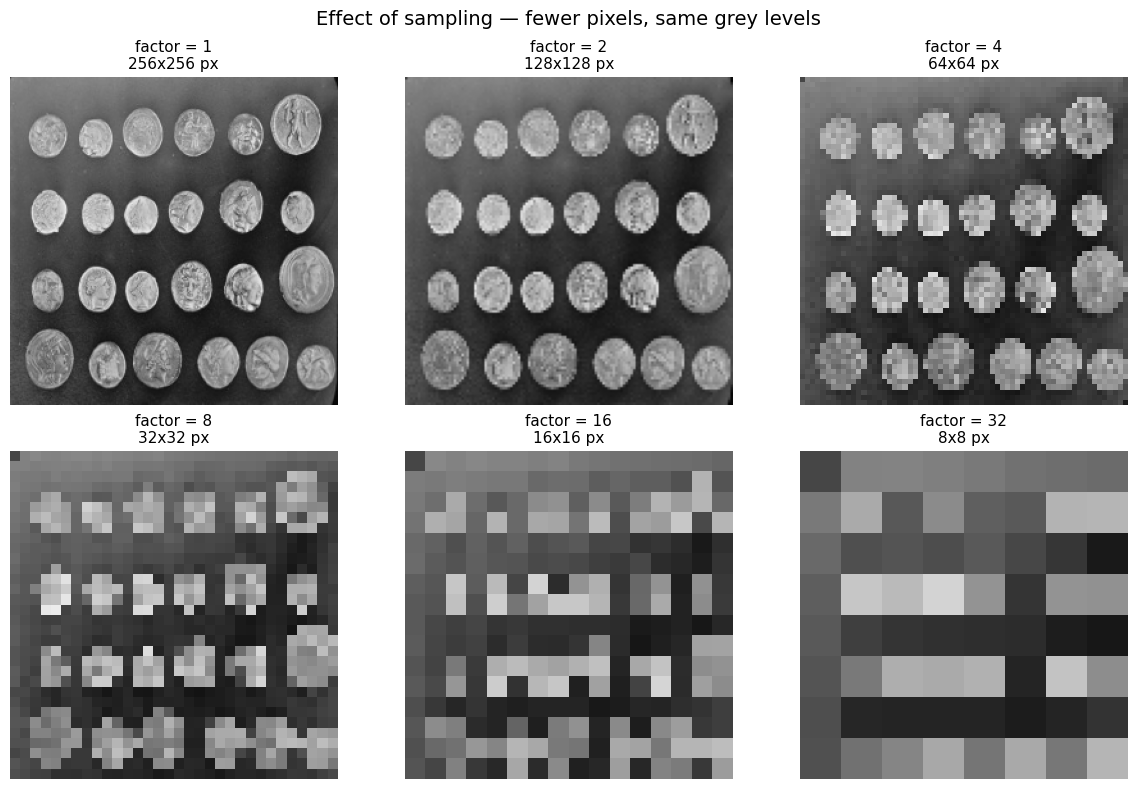

factor  1: shape (256, 256)   pixels   65536
factor  2: shape (128, 128)   pixels   16384
factor  4: shape (64, 64)     pixels    4096
factor  8: shape (32, 32)     pixels    1024
factor 16: shape (16, 16)     pixels     256
factor 32: shape (8, 8)       pixels      64


In [7]:
factors = [1, 2, 4, 8, 16, 32]
imgs, titles = [], []
for f in factors:
    s = sample_image(original_image, f) if f > 1 else original_image
    imgs.append(s)
    titles.append(f"factor = {f}\n{s.shape[1]}x{s.shape[0]} px")

show(imgs, titles, cols=3, suptitle="Effect of sampling — fewer pixels, same grey levels")

for f, im in zip(factors, imgs):
    print(f"factor {f:>2}: shape {str(im.shape):<12} pixels {im.size:>7}")

### 1.5 Task #1 — changing the quantization levels

Each image below keeps all 256x256 pixels and only reduces the number of grey values.

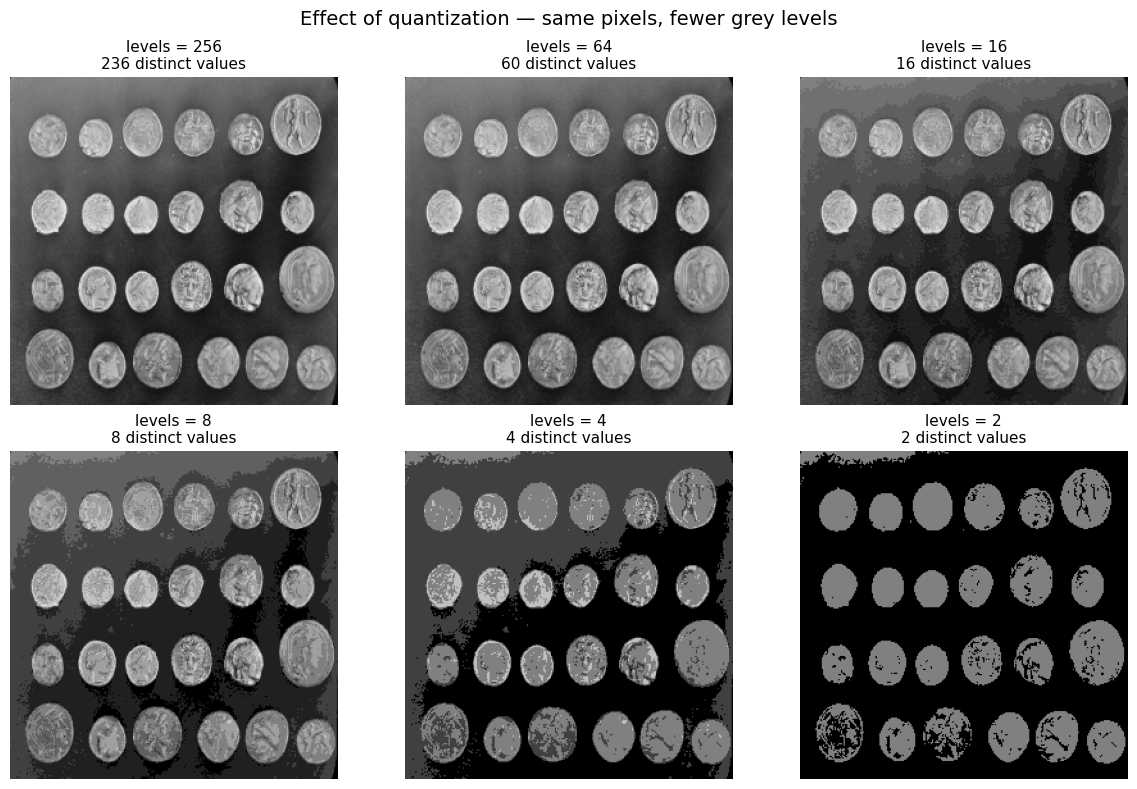

In [8]:
levels_list = [256, 64, 16, 8, 4, 2]
imgs, titles = [], []
for lv in levels_list:
    q = quantize_image(original_image, lv) if lv < 256 else original_image
    imgs.append(q)
    titles.append(f"levels = {lv}\n{len(np.unique(q))} distinct values")

show(imgs, titles, cols=3, suptitle="Effect of quantization — same pixels, fewer grey levels")

### 1.6 Task #1 — the two effects together

Sampling is applied down the rows, quantization across the columns.

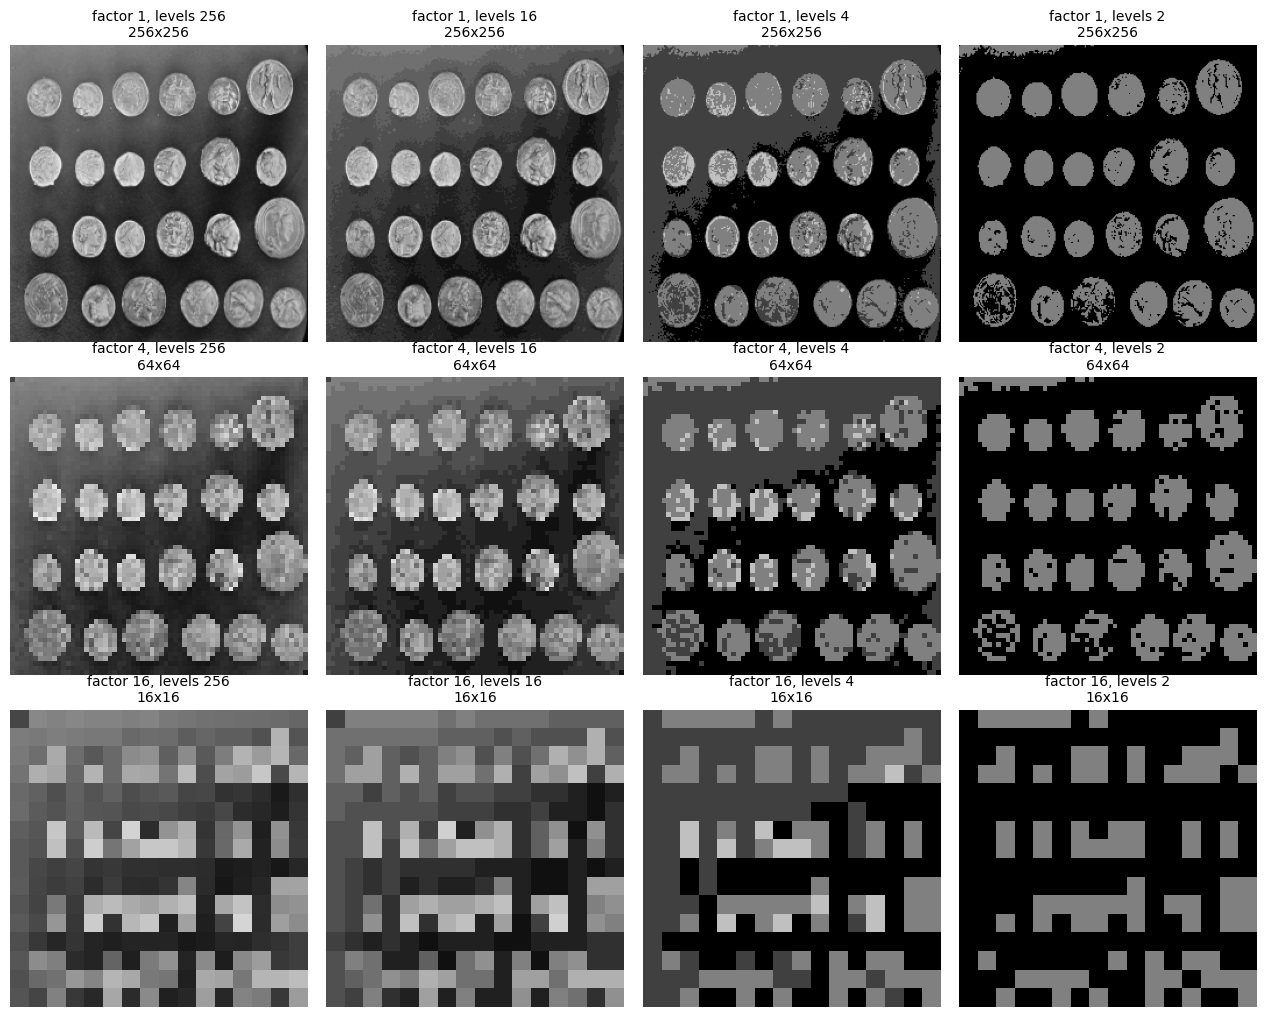

In [9]:
fac_grid = [1, 4, 16]
lev_grid = [256, 16, 4, 2]

fig, axes = plt.subplots(len(fac_grid), len(lev_grid),
                         figsize=(3.2 * len(lev_grid), 3.4 * len(fac_grid)))
for i, f in enumerate(fac_grid):
    base = sample_image(original_image, f) if f > 1 else original_image
    for j, lv in enumerate(lev_grid):
        im = quantize_image(base, lv) if lv < 256 else base
        ax = axes[i, j]
        ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"factor {f}, levels {lv}\n{im.shape[1]}x{im.shape[0]}", fontsize=10)
        ax.axis('off')
plt.tight_layout()
plt.show()

### 1.7 Observations

* **Sampling** removes pixel positions. The image becomes blocky and fine detail disappears
  first — edges turn into visible steps. The array gets smaller, so the file gets smaller.
* **Quantization** removes intensity values. The array keeps its size, but smooth gradients
  break into flat bands. This artefact is called **false contouring**, and it is most visible
  in areas that change gradually.
* The two are independent. An image can have many pixels and few grey levels, or few pixels
  and many grey levels, and the two failures look completely different.
* Below about 16 levels the banding becomes obvious; at 2 levels the image is pure black and
  white and only the overall shape survives.

---
## Part 2 — Arithmetic operations

### 2.1 The manual's addition example

Two images are opened with PIL, resized to 400x400, converted to arrays and added.

im1arr: (400, 400) uint8
im2arr: (400, 400) uint8


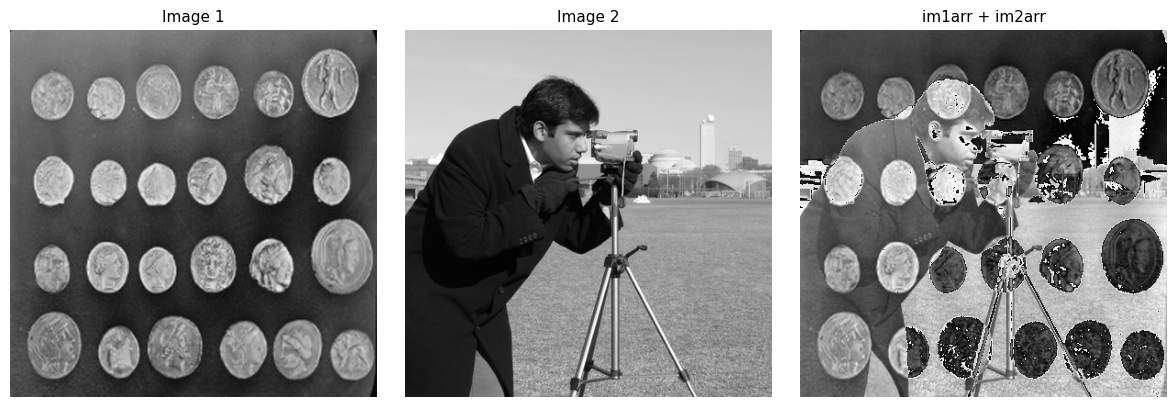

In [10]:
img1 = Image.open(img_path('gray_256.tif'))
img2 = Image.open(img_path('cameraman.tif'))

resize_to = (400, 400)
img1 = img1.resize(resize_to, Image.Resampling.LANCZOS)
img2 = img2.resize(resize_to, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

print("im1arr:", im1arr.shape, im1arr.dtype)
print("im2arr:", im2arr.shape, im2arr.dtype)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition)

show([im1arr, im2arr, addition],
     ["Image 1", "Image 2", "im1arr + im2arr"],
     cols=3)

### 2.2 The overflow problem

The result above contains bright speckles in places where both images were bright — exactly
where the sum should have been *brightest*. This is not a rendering glitch.

Both arrays are `uint8`, which can only hold 0 to 255. NumPy does not clip; it **wraps
around**. So `200 + 100` gives 300, and 300 mod 256 is **44** — a bright pixel plus a bright
pixel produces a dark one.

The cell below counts how many pixels are affected and proves the wrap-around directly.

In [11]:
true_sum = im1arr.astype(np.int16) + im2arr.astype(np.int16)   # computed in 16 bits
overflowed = true_sum > 255

print("pixels that exceed 255 :", int(overflowed.sum()),
      f"({100 * overflowed.mean():.1f}% of the image)")
print("largest true sum       :", int(true_sum.max()))
print()
print("a concrete example:")
r, c = np.argwhere(overflowed)[0]
print(f"  im1arr[{r},{c}] = {im1arr[r, c]}")
print(f"  im2arr[{r},{c}] = {im2arr[r, c]}")
print(f"  true sum        = {int(true_sum[r, c])}")
print(f"  uint8 result    = {addition[r, c]}   <- wrapped around (mod 256)")

pixels that exceed 255 : 69116 (43.2% of the image)
largest true sum       : 487

a concrete example:
  im1arr[0,0] = 60
  im2arr[0,0] = 200
  true sum        = 260
  uint8 result    = 4   <- wrapped around (mod 256)


### 2.3 Doing it correctly

Two standard fixes, both of which keep the result inside 0–255:

* **Saturating addition** — anything above 255 becomes 255. This is what `cv2.add` does,
  and `np.clip` on a wider type does the same thing.
* **Averaging (blending)** — divide the sum by 2, which can never overflow and keeps the
  contribution of both images visible.

np.clip and cv2.add identical: True


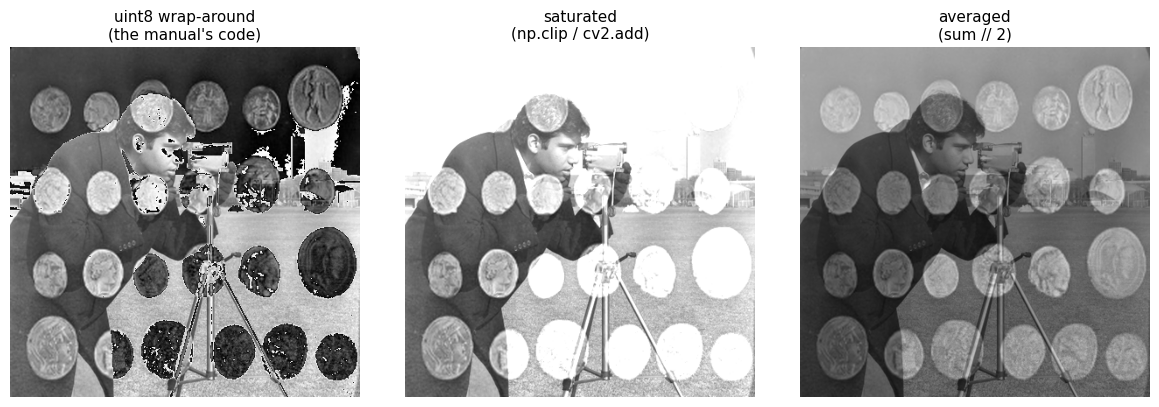

In [12]:
add_saturated = np.clip(true_sum, 0, 255).astype(np.uint8)   # same as cv2.add
add_cv2       = cv2.add(im1arr, im2arr)                       # OpenCV saturates by default
add_average   = (true_sum // 2).astype(np.uint8)              # blend

print("np.clip and cv2.add identical:", np.array_equal(add_saturated, add_cv2))

show([addition, add_saturated, add_average],
     ["uint8 wrap-around\n(the manual's code)",
      "saturated\n(np.clip / cv2.add)",
      "averaged\n(sum // 2)"],
     cols=3)

### 2.4 Task #2a — subtract two images

Subtraction has the mirror problem: `uint8` cannot go below 0, so `50 - 100` wraps to 206.
Three meaningful versions are shown.

pixels below 0 : 99629 (62.3% of the image)
range of the true difference: -236 to 240
matches cv2.subtract: True
matches cv2.absdiff : True


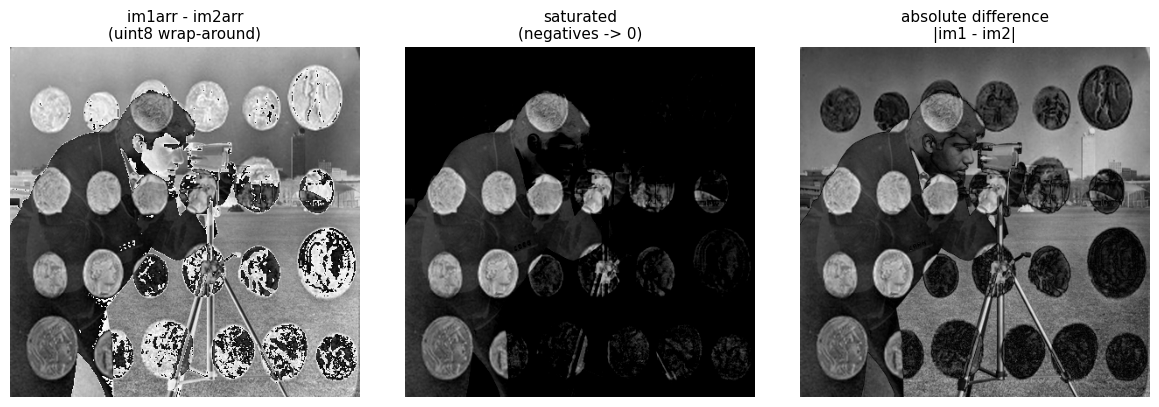

In [13]:
diff_wrapped   = im1arr - im2arr                                          # wraps under 0
true_diff      = im1arr.astype(np.int16) - im2arr.astype(np.int16)
diff_saturated = np.clip(true_diff, 0, 255).astype(np.uint8)              # cv2.subtract
diff_absolute  = np.abs(true_diff).astype(np.uint8)                       # cv2.absdiff

print("pixels below 0 :", int((true_diff < 0).sum()),
      f"({100 * (true_diff < 0).mean():.1f}% of the image)")
print("range of the true difference:", int(true_diff.min()), "to", int(true_diff.max()))
print("matches cv2.subtract:", np.array_equal(diff_saturated, cv2.subtract(im1arr, im2arr)))
print("matches cv2.absdiff :", np.array_equal(diff_absolute, cv2.absdiff(im1arr, im2arr)))

show([diff_wrapped, diff_saturated, diff_absolute],
     ["im1arr - im2arr\n(uint8 wrap-around)",
      "saturated\n(negatives -> 0)",
      "absolute difference\n|im1 - im2|"],
     cols=3)

The absolute difference is the version normally used in practice: it is symmetric, it never
loses information to clipping, and it is the standard way to compare two images — a black
result means the two images are identical at that pixel.

### 2.5 Task #2b — add a constant value of 175

Adding a constant brightens every pixel by the same amount. With a constant as large as 175,
the overflow issue dominates: any pixel above 80 already exceeds 255.

pixels that exceed 255 : 86378 (54.0% of the image)
original  mean: 96.9
saturated mean: 241.2


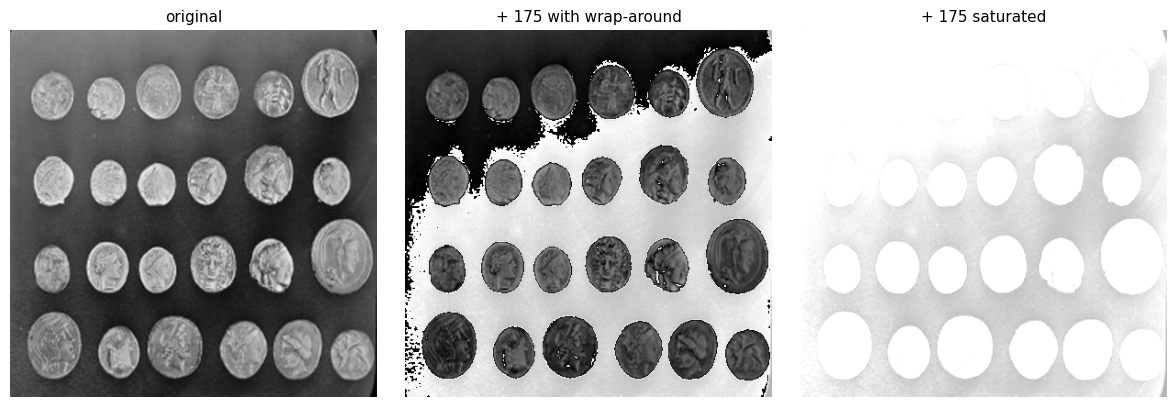

In [14]:
C = 175

const_wrapped   = im1arr + np.uint8(C)                                    # wraps
const_saturated = np.clip(im1arr.astype(np.int16) + C, 0, 255).astype(np.uint8)

print("pixels that exceed 255 :", int((im1arr.astype(np.int16) + C > 255).sum()),
      f"({100 * (im1arr.astype(np.int16) + C > 255).mean():.1f}% of the image)")
print("original  mean:", round(float(im1arr.mean()), 1))
print("saturated mean:", round(float(const_saturated.mean()), 1))

show([im1arr, const_wrapped, const_saturated],
     ["original", f"+ {C} with wrap-around", f"+ {C} saturated"],
     cols=3)

The saturated version is a genuinely brighter image whose bright areas have merged into
solid white — the detail there is lost, but the result still looks like a photograph. The
wrapped version is unusable: bright regions have become dark, so the picture is inverted in
patches.

---
## Part 3 — Sets and logical operations

### 3.1 The two sets

`A` is a disk and `B` is a square, positioned so that they overlap. Both are binary images:
every pixel is either 0 (not in the set) or 255 (in the set).

A: (400, 400) uint8 values: [  0 255]
B: (400, 400) uint8 values: [  0 255]
pixels in A       : 45225
pixels in B       : 32400
pixels in A and B : 12140


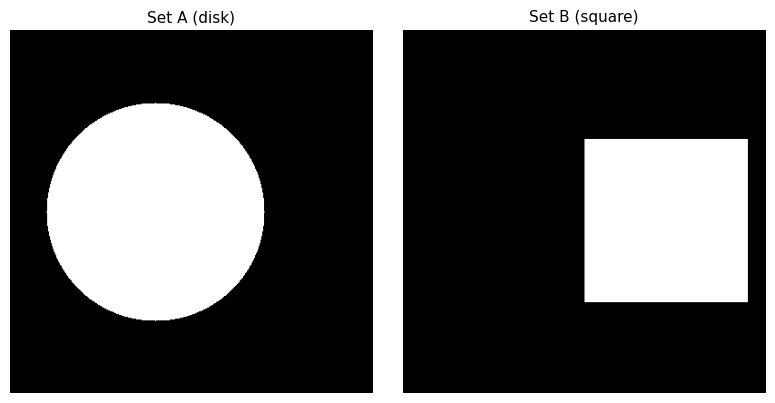

In [15]:
img3 = Image.open(img_path('A.png'))
img4 = Image.open(img_path('B.png'))

resize_to = (400, 400)
img3 = img3.resize(resize_to, Image.Resampling.LANCZOS)
img4 = img4.resize(resize_to, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

print("A:", im3arr.shape, im3arr.dtype, "values:", np.unique(im3arr))
print("B:", im4arr.shape, im4arr.dtype, "values:", np.unique(im4arr))
print("pixels in A       :", int((im3arr > 0).sum()))
print("pixels in B       :", int((im4arr > 0).sum()))
print("pixels in A and B :", int(((im3arr > 0) & (im4arr > 0)).sum()))

show([im3arr, im4arr], ["Set A (disk)", "Set B (square)"], cols=2)

### 3.2 The manual's union

`|` is the bitwise OR. On values that are only 0 or 255 it behaves exactly as set union:
a pixel is in the result if it is in A **or** in B.

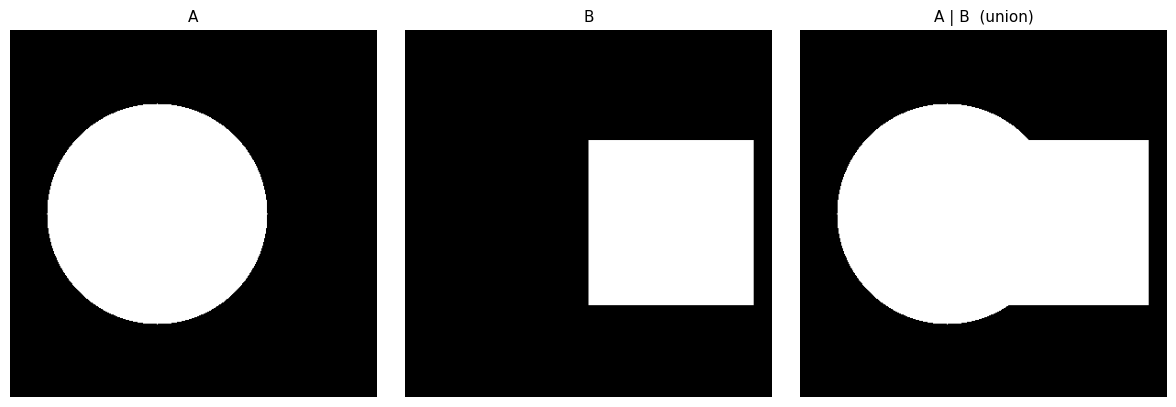

pixels in the union: 65485


In [16]:
union = im4arr | im3arr
resultImage2 = Image.fromarray(union)

show([im3arr, im4arr, union], ["A", "B", "A | B  (union)"], cols=3)
print("pixels in the union:", int((union > 0).sum()))

### 3.3 All five operations on the binary sets

| Operation | Meaning | NumPy |
|---|---|---|
| Union | in A **or** in B | `A \| B` |
| Intersection | in A **and** in B | `A & B` |
| Difference A \ B | in A but **not** in B | `A & ~B` |
| Symmetric difference | in exactly **one** of them | `A ^ B` |
| Complement | **not** in A | `~A` |

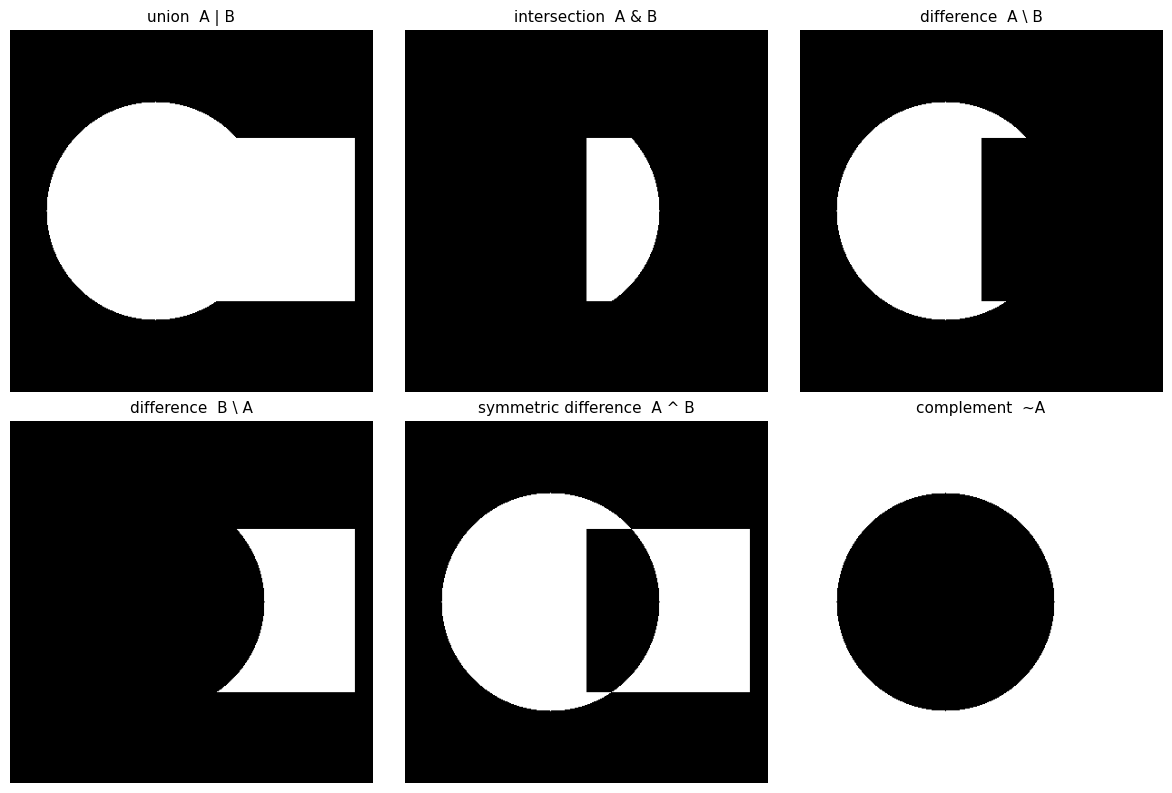

union              65485 pixels
intersection       12140 pixels
A \ B              33085 pixels
B \ A              20260 pixels
symmetric diff     53345 pixels
~A                114775 pixels


In [17]:
u   = im3arr | im4arr           # union
i   = im3arr & im4arr           # intersection
dAB = im3arr & ~im4arr          # difference  A \ B
dBA = im4arr & ~im3arr          # difference  B \ A
sym = im3arr ^ im4arr           # symmetric difference
comp = ~im3arr                  # complement of A

show([u, i, dAB, dBA, sym, comp],
     ["union  A | B", "intersection  A & B", "difference  A \\ B",
      "difference  B \\ A", "symmetric difference  A ^ B", "complement  ~A"],
     cols=3)

for name, arr in [("union", u), ("intersection", i), ("A \\ B", dAB),
                  ("B \\ A", dBA), ("symmetric diff", sym), ("~A", comp)]:
    print(f"{name:<16}{int((arr > 0).sum()):>8} pixels")

### 3.4 Checking the set identities

If the operations are correct, the classical identities of set theory must hold pixel by
pixel. This is a genuine verification, not a demonstration.

In [18]:
checks = {
    "|A u B| = |A| + |B| - |A n B|":
        (u > 0).sum() == (im3arr > 0).sum() + (im4arr > 0).sum() - (i > 0).sum(),
    "A ^ B = (A u B) - (A n B)":
        np.array_equal(sym, u & ~i),
    "A ^ B = (A\\B) u (B\\A)":
        np.array_equal(sym, dAB | dBA),
    "De Morgan: ~(A u B) = ~A & ~B":
        np.array_equal(~u, ~im3arr & ~im4arr),
    "De Morgan: ~(A n B) = ~A | ~B":
        np.array_equal(~i, ~im3arr | ~im4arr),
    "A\\B = A - (A n B)":
        np.array_equal(dAB, im3arr & ~i),
}
for name, ok in checks.items():
    print(f"{'OK ' if ok else 'FAIL'} {name}")

OK  |A u B| = |A| + |B| - |A n B|
OK  A ^ B = (A u B) - (A n B)
OK  A ^ B = (A\B) u (B\A)
OK  De Morgan: ~(A u B) = ~A & ~B
OK  De Morgan: ~(A n B) = ~A | ~B
OK  A\B = A - (A n B)


### 3.5 Task #2c, #2d, #2e — the same operations on **grayscale** images

This is where the bitwise operators stop being appropriate. On a grayscale image the pixel
values are not membership flags, they are intensities, and `|` would combine them bit by bit
— which is arithmetically meaningless.

The standard grayscale generalisation treats each pixel value as a *degree* of membership:

| Operation | Grayscale definition | NumPy |
|---|---|---|
| Union | the brighter of the two | `np.maximum(A, B)` |
| Intersection | the darker of the two | `np.minimum(A, B)` |
| Complement | invert the intensity | `255 - A` |
| Difference A \ B | A intersected with the complement of B | `np.minimum(A, 255 - B)` |
| Symmetric difference | union minus intersection | `np.maximum - np.minimum` = `\|A - B\|` |

These reduce to exactly the binary definitions when the values are only 0 and 255, so they
are a true generalisation rather than a different set of rules.

symmetric difference equals |A - B| : True
union  >= both inputs everywhere    : True
intersection <= both inputs         : True


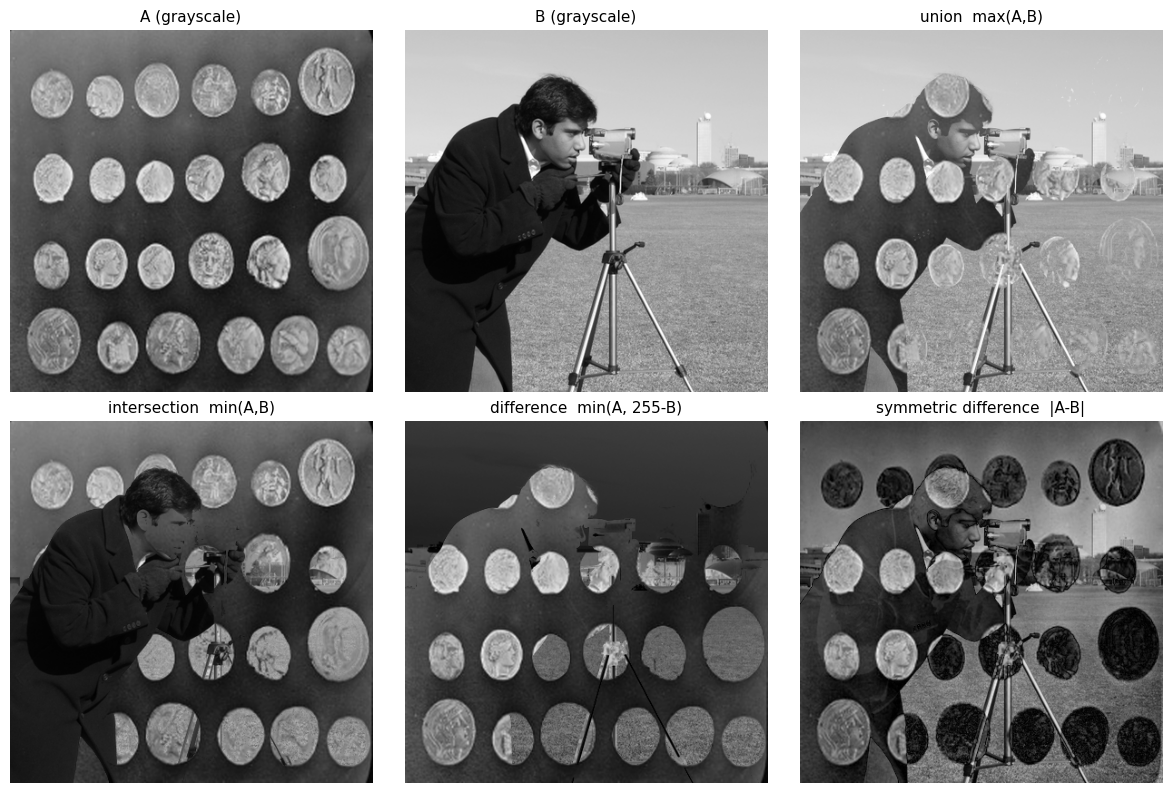

In [19]:
A, B = im1arr, im2arr          # the two grayscale images from Part 2

g_union = np.maximum(A, B)                              # union
g_inter = np.minimum(A, B)                              # intersection
g_compA = 255 - A                                       # complement of A
g_dAB   = np.minimum(A, 255 - B)                        # difference  A \ B
g_dBA   = np.minimum(B, 255 - A)                        # difference  B \ A
g_sym   = g_union - g_inter                             # symmetric difference

print("symmetric difference equals |A - B| :",
      np.array_equal(g_sym, cv2.absdiff(A, B)))
print("union  >= both inputs everywhere    :",
      bool(np.all((g_union >= A) & (g_union >= B))))
print("intersection <= both inputs         :",
      bool(np.all((g_inter <= A) & (g_inter <= B))))

show([A, B, g_union, g_inter, g_dAB, g_sym],
     ["A (grayscale)", "B (grayscale)",
      "union  max(A,B)", "intersection  min(A,B)",
      "difference  min(A, 255-B)", "symmetric difference  |A-B|"],
     cols=3)

### 3.6 Why the bitwise operators fail on grayscale

A direct comparison. `A | B` produces a harsh, noisy image because the OR is applied to the
individual bits of the intensity values: 100 | 30 is 126, which corresponds to nothing
meaningful about brightness.

max(A,B) and A|B identical: False

a single pixel:
  A =  60  (00111100)
  B = 200  (11001000)
  A | B      = 252  (11111100)  <- bit pattern
  max(A, B)  = 200   <- the brighter of the two


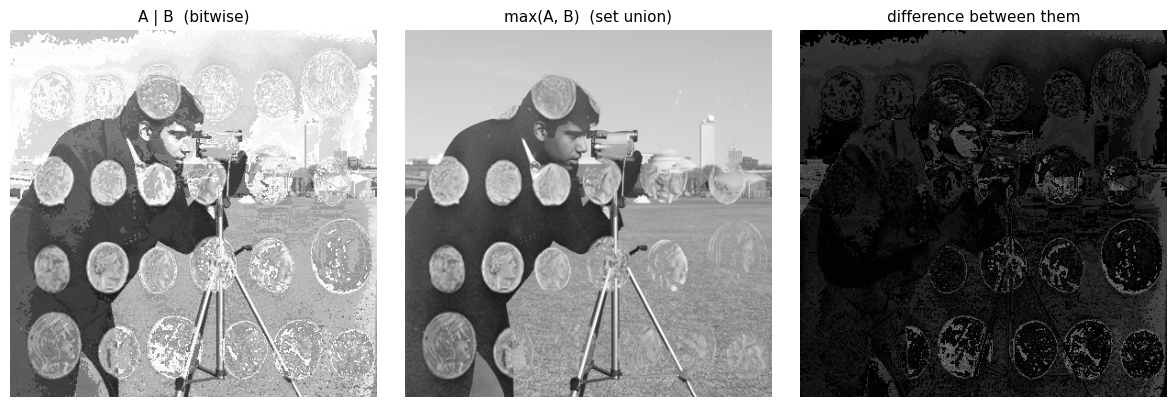

In [20]:
bitwise_union = A | B
print("max(A,B) and A|B identical:", np.array_equal(g_union, bitwise_union))
print()
print("a single pixel:")
print(f"  A = {A[0, 0]:>3}  ({A[0, 0]:08b})")
print(f"  B = {B[0, 0]:>3}  ({B[0, 0]:08b})")
print(f"  A | B      = {bitwise_union[0, 0]:>3}  ({bitwise_union[0, 0]:08b})  <- bit pattern")
print(f"  max(A, B)  = {g_union[0, 0]:>3}   <- the brighter of the two")

show([bitwise_union, g_union, cv2.absdiff(bitwise_union, g_union)],
     ["A | B  (bitwise)", "max(A, B)  (set union)", "difference between them"],
     cols=3)

### 3.7 Summary figure

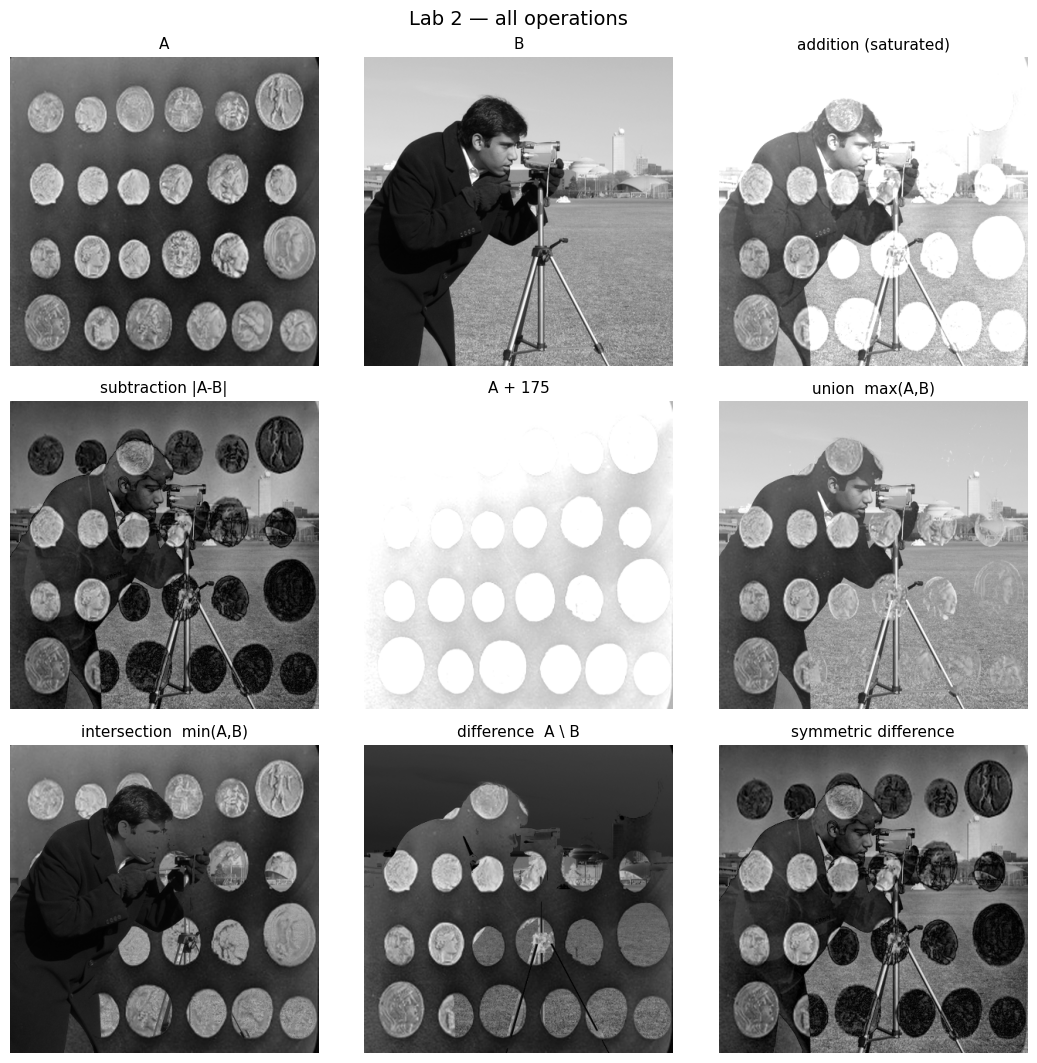

Saved: output/lab2_summary.png


In [21]:
ops = [(A, "A"), (B, "B"),
       (cv2.add(A, B), "addition (saturated)"),
       (cv2.absdiff(A, B), "subtraction |A-B|"),
       (np.clip(A.astype(np.int16) + 175, 0, 255).astype(np.uint8), "A + 175"),
       (g_union, "union  max(A,B)"),
       (g_inter, "intersection  min(A,B)"),
       (g_dAB, "difference  A \\ B"),
       (g_sym, "symmetric difference")]

show([o[0] for o in ops], [o[1] for o in ops], cols=3, size=3.6,
     suptitle="Lab 2 — all operations")

plt.figure(figsize=(11, 11))
for k, (im, t) in enumerate(ops, 1):
    plt.subplot(3, 3, k)
    plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(t, fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.savefig('output/lab2_summary.png', dpi=120, bbox_inches='tight')
plt.close()
print("Saved: output/lab2_summary.png")

---
## Conclusion

**Sampling and quantization** are the two independent choices that define a digital image.
Sampling fixes the number of pixels, quantization fixes the number of intensity values each
pixel may take. Reducing the first makes the image blocky; reducing the second produces
false contouring. The manual's quantization formula is exact only when the number of levels
divides 256, because `256 // levels` truncates the step size — with 9 levels it can actually
produce 10 distinct values.

**Arithmetic operations** are ordinary NumPy arithmetic, but the `uint8` data type is the
thing to watch. It wraps around instead of clipping, so a sum above 255 or a difference below
0 silently becomes a wrong value: bright plus bright turns dark. The fix is to compute in a
wider type and clip, which is what `cv2.add`, `cv2.subtract` and `cv2.absdiff` do internally.
This is the single most common source of wrong results in image arithmetic.

**Set and logical operations** work directly on binary images, where `|`, `&`, `^` and `~`
correspond exactly to union, intersection, symmetric difference and complement — and the
classical set identities, including De Morgan's laws, were verified pixel by pixel. On
grayscale images the bitwise operators are no longer meaningful, because the values are
intensities rather than membership flags. The correct generalisation uses `np.maximum` for
union and `np.minimum` for intersection, which reduces to the binary definitions when the
only values present are 0 and 255.

Across all three parts the same point holds: an image is an array, and image processing is
array processing — provided the data type is respected.

---

### References
- OpenCV geometric transformations: https://docs.opencv.org/3.4/da/d54/group__imgproc__transform.html
- Pillow documentation: https://pillow.readthedocs.io/
- NumPy Basics cheat sheet (course resources)
- scikit-image sample data: https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html